# Fig. 1 and the other main-text figures

The figures the main text carries: the headline convergence panels (**Fig. 1 =
`headline_curves`**), the cost/memory scaling figure, Sven's `k` sweeps and the
hyperparameter landscape, plus the all-seed appendix versions.

`headline_curves` is the one to reach for first: `methods` chooses the field it draws
(the front of the field, or every baseline), and the legend, labels and aspect ratio are
ordinary knobs.

## How this works

```python
f = pf.make('<figure>')          # draws it, writes NOTHING
f.show(zoom=2)                   # magnified screen copy (the PDF keeps its page size)
f.ax(0).set_ylabel('...')        # edit the matplotlib objects however you like
f.fig.set_size_inches(5.5, 2.4)  # f.axes = the builder's layout, f.flat = every panel
f.save()                         # writes iclr_manuscript/figures_iclr/<group>/<figure>.pdf,
                                 # the PNG twin and the provenance sidecar -- exactly as
                                 # `python -m paper_assets` does
```

Two kinds of option:

* **the figure's own knobs** — what it draws (methods, scans, panels), its geometry
  (`fraction`, `aspect`), line weights, legend placement. `pf.info('<figure>')` lists them
  with their defaults.
* **the generic cosmetics**, on every figure: `figsize`, `xlabel`, `ylabel`, `title`,
  `xlim`, `ylim`, `xscale`, `yscale`, `legend`, `suptitle`, `grid`, `tick_labelsize`,
  `rc`. Each takes a value for all panels, a list by panel position, or a dict keyed by
  panel index — e.g. `ylabel={0: 'Validation loss'}`, `legend={'loc': 'lower left',
  'ncol': 6, 'fontsize': 5}`.

Pass either to `pf.make(...)` for a one-off, or **pin** it so the paper build draws it
that way too:

```python
pf.pin('headline_curves', methods='all', aspect=0.95)   # -> paper_assets/figure_overrides.yaml
pf.rebuild('headline_curves')                           # draw with the pinned options + save
pf.unpin('headline_curves')                             # back to the builder's default
```

Pinned options live in `analysis/paper_assets/figure_overrides.yaml`, which
`python -m paper_assets` reads, so a full rebuild reproduces your version instead of
reverting it. Nothing in this notebook writes until you call `save()` or `rebuild()`, so
re-running it top to bottom is safe.

**A note on size.** These are drawn at their true size on the page (a 0.32-linewidth
panel is 1.76 in wide, 7 pt type), so they look small inline; `show(zoom=...)` only
magnifies the screen copy. To judge the type size, look at the PNG twin under
`agent_lab/paper_assets/<group>/` after saving — it is written at the physical size.

In [1]:
%matplotlib inline
import os
import sys

# This notebook lives in analysis/notebooks/paper/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))

import paper_assets.notebook as pf

pf.figures('main')

,figure,group,module,knobs,pinned,what
0,allseed_curves,main,main,"aspect, clip_factor, clip_headroom, clip_note_...",-,"F13: every method, confirmation seeds, on thre..."
1,allseed_curves_ce_lm,main,main,"aspect, clip_factor, clip_headroom, clip_note_...",-,"F13, continued: the same three axes for MNIST-..."
2,cost_memory,main,main,"arch_tick_fontsize, aspect, capture_note, capt...",-,F3: step time (left) and peak GPU memory (righ...
3,headline_curves,main,main,"aspect, extra_h, figure_legend_kw, figure_lege...",-,F1: validation loss vs epoch (top) and vs stan...
4,headline_curves_all,main,main,"aspect, extra_h, figure_legend_kw, figure_lege...",-,"F1, appendix version: the same panels with EVE..."
5,hparam_landscape,main,main,"aspect, cmap, cmap_range, extra_h, font_fracti...",-,F12 bottom: Sven's final-loss landscape over k...
6,k_sweeps,main,main,"aspect, axis, band_alpha, cmap, cmap_range, ex...",-,F12 top: Sven's k sweep at each scan's SELECTE...


## `allseed_curves`

F13: every method, confirmation seeds, on three axes (val vs epoch, val vs standalone time, train vs epoch) for 1D regression, the polynomial and MNIST label regression.

Its own knobs:

* `aspect` — default `0.82`
* `clip_factor` — default `20.0`
* `clip_headroom` — default `50.0`
* `clip_note_fontsize` — default `4.4`
* `clip_note_xy` — default `[0.97, 0.95]`
* `clip_outliers` — default `True`
* `columns` — default `[['val', 'epoch'], ['val', 'time'], ['train', 'epoch']]`
* `extra_h` — default `0.7`
* `figure_legend_kw` — default `{'loc': 'outside lower center', 'fontsize': 6.0, 'handlelength': 1.2, 'columnspacing': 0.8, 'ncol': 5}`
* `font_fraction` — default `0.32`
* `fraction` — default `0.32`
* `lw` — default `0.85`
* `methods` — default `'all'`
* `scans` — default `['toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression']`
* `sven_lw` — default `1.8`
* `top_n` — default `5`


Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)
Loaded 225 runs from ../experiment_results/_cache/toy_1d_scan_confirm.slim.pkl (slim cache)


Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)
Loaded 225 runs from ../experiment_results/_cache/polynomial_scan_confirm.slim.pkl (slim cache)


Loaded 1360 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)
Loaded 70 runs from ../experiment_results/_cache/mnist_scan_labelRegression_confirm.slim.pkl (slim cache)


Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)
Loaded 70 runs from ../experiment_results/_cache/mnist_scan_ce_confirm.slim.pkl (slim cache)


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_confirm.slim.pkl (slim cache)


Loaded 785 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)
Loaded 60 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan_confirm.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)


Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_confirm.slim.pkl (slim cache)


Loaded 75 runs from ../experiment_results/_cache/toy_1d_scan_timing.slim.pkl (slim cache)


Loaded 75 runs from ../experiment_results/_cache/polynomial_scan_timing.slim.pkl (slim cache)


Loaded 70 runs from ../experiment_results/_cache/mnist_scan_labelRegression_timing.slim.pkl (slim cache)


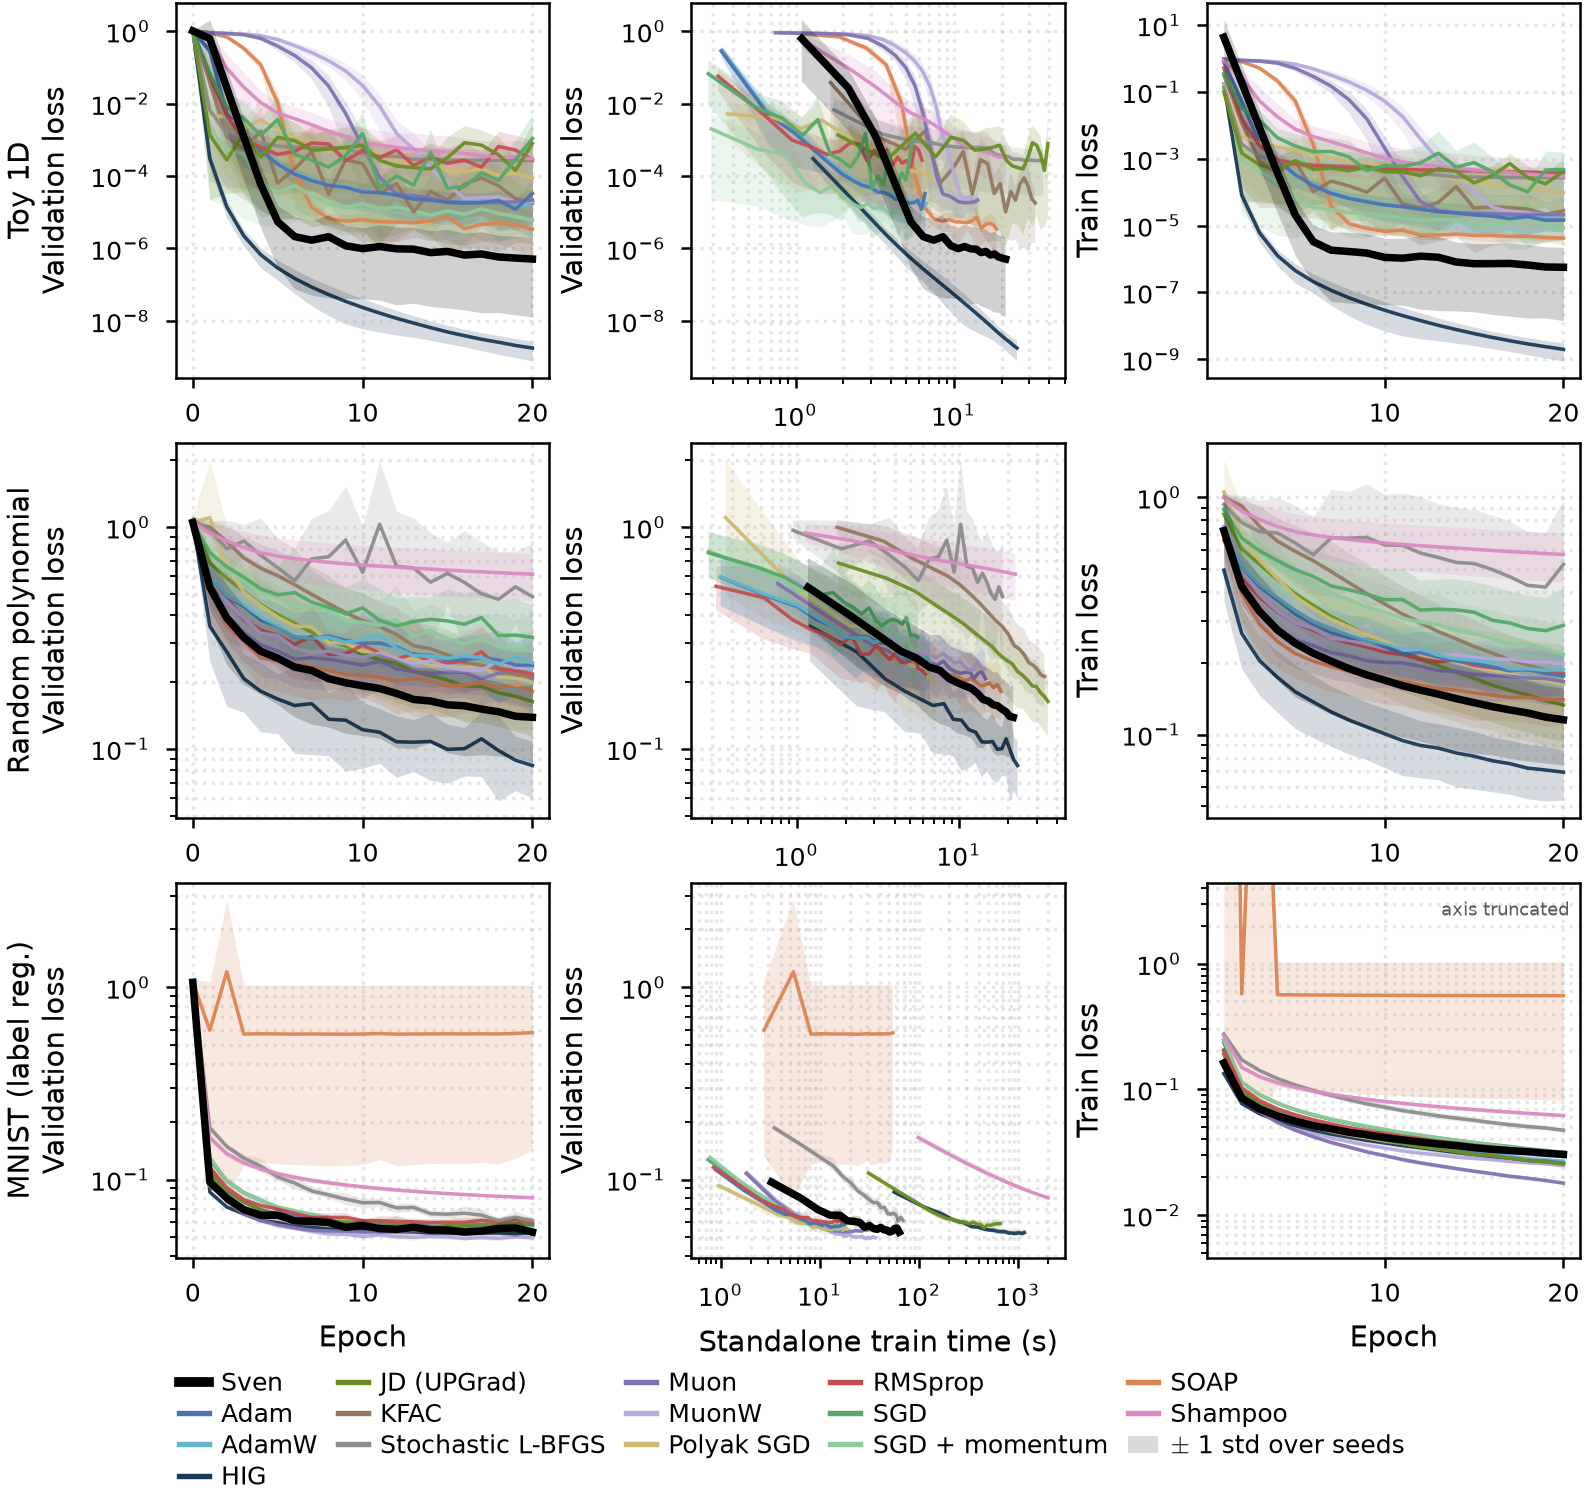

allseed_curves: 5.28 x 5.03 in on the page (shown at 2x)


In [2]:
f = pf.make('allseed_curves')
f.show(zoom=2)

In [3]:
# --- edit allseed_curves -------------------------------------------------------
# its own knobs: aspect, clip_factor, clip_headroom, clip_note_fontsize, clip_note_xy, clip_outliers, columns, extra_h, figure_legend_kw, font_fraction, fraction, lw, methods, scans, sven_lw, top_n
# f = pf.make('allseed_curves', aspect=0.82, clip_factor=20.0, clip_headroom=50.0)
# f = pf.make('allseed_curves', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('allseed_curves', aspect=0.95)              # ... and make the CLI agree

## `allseed_curves_ce_lm`

F13, continued: the same three axes for MNIST-CE and nanoGPT.

Its own knobs:

* `aspect` — default `0.82`
* `clip_factor` — default `20.0`
* `clip_headroom` — default `50.0`
* `clip_note_fontsize` — default `4.4`
* `clip_note_xy` — default `[0.97, 0.95]`
* `clip_outliers` — default `True`
* `columns` — default `[['val', 'epoch'], ['val', 'time'], ['train', 'epoch']]`
* `extra_h` — default `0.7`
* `figure_legend_kw` — default `{'loc': 'outside lower center', 'fontsize': 6.0, 'handlelength': 1.2, 'columnspacing': 0.8, 'ncol': 5}`
* `font_fraction` — default `0.32`
* `fraction` — default `0.32`
* `lw` — default `0.85`
* `methods` — default `'all'`
* `scans` — default `['mnist_scan_ce', 'exp_nanogpt_speedrun']`
* `sven_lw` — default `1.8`
* `top_n` — default `5`


Loaded 70 runs from ../experiment_results/_cache/mnist_scan_ce_timing.slim.pkl (slim cache)


Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_timing.slim.pkl (slim cache)


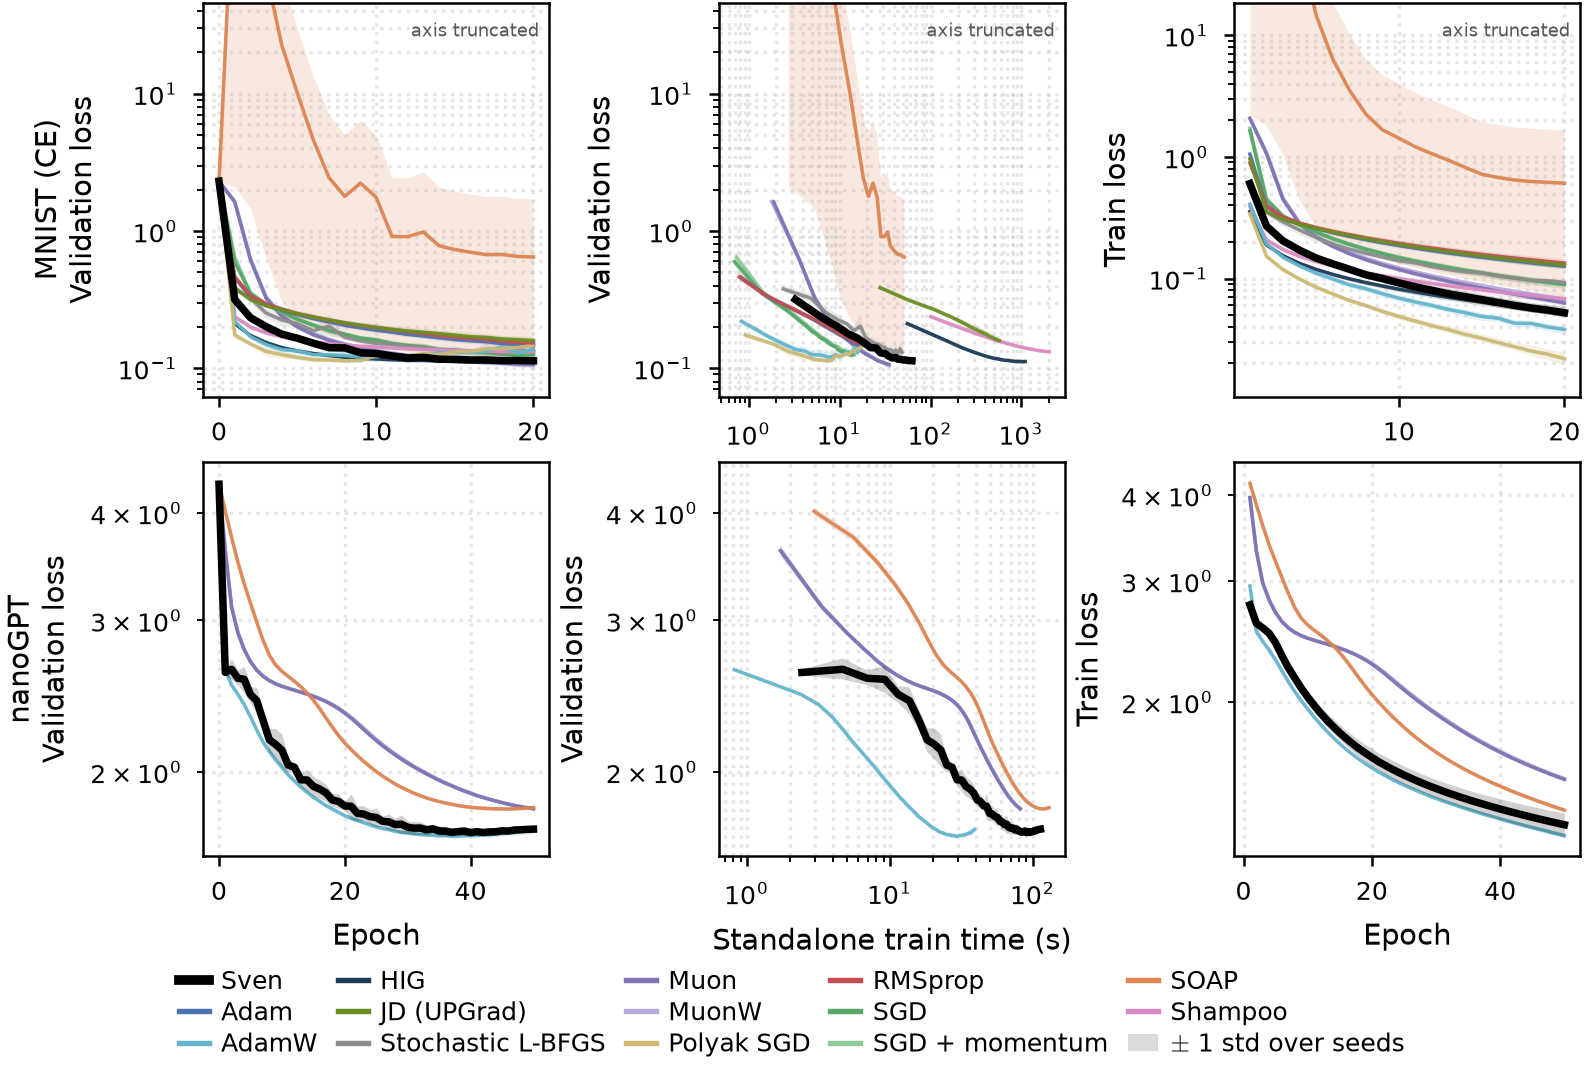

allseed_curves_ce_lm: 5.28 x 3.59 in on the page (shown at 2x)


In [4]:
f = pf.make('allseed_curves_ce_lm')
f.show(zoom=2)

In [5]:
# --- edit allseed_curves_ce_lm -------------------------------------------------------
# its own knobs: aspect, clip_factor, clip_headroom, clip_note_fontsize, clip_note_xy, clip_outliers, columns, extra_h, figure_legend_kw, font_fraction, fraction, lw, methods, scans, sven_lw, top_n
# f = pf.make('allseed_curves_ce_lm', aspect=0.82, clip_factor=20.0, clip_headroom=50.0)
# f = pf.make('allseed_curves_ce_lm', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('allseed_curves_ce_lm', aspect=0.95)              # ... and make the CLI agree

## `cost_memory`

F3: step time (left) and peak GPU memory (right) against the parameter count over five architectures, from the standalone timing pass.

Its own knobs:

* `arch_tick_fontsize` — default `4.4`
* `aspect` — default `0.8`
* `capture_note` — default `True`
* `capture_note_fontsize` — default `4.8`
* `cluster_decades` — default `0.5`
* `extra_h` — default `0.34`
* `figure_legend_kw` — default `{'loc': 'outside lower center', 'ncol': 6, 'fontsize': 6.2, 'handlelength': 1.2, 'columnspacing': 0.8}`
* `font_fraction` — default `0.49`
* `fraction` — default `0.49`
* `lw` — default `1.0`
* `methods` — default `['Sven', 'Adam', 'MuonW', 'HIG', 'LBFGS', 'SGD']`
* `ms` — default `2.6`
* `scans` — default `['toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression', 'exp_nanogpt_speedrun', 'cifar10_resnet_scan_labelRegression']`
* `sven_lw` — default `1.8`
* `sven_ms` — default `3.4`


Loaded 55 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression_timing.slim.pkl (slim cache)


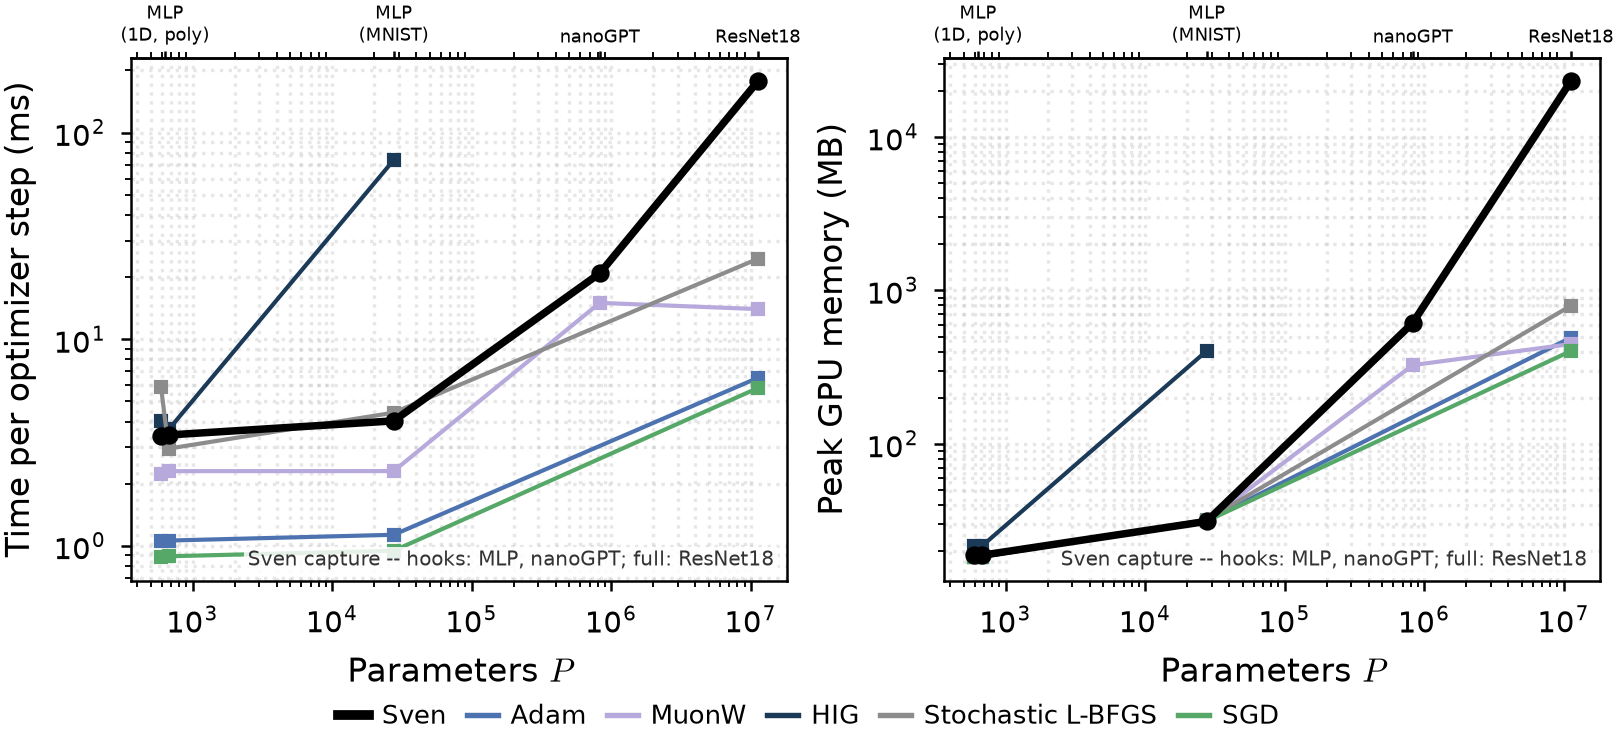

cost_memory: 5.39 x 2.50 in on the page (shown at 2x)


In [6]:
f = pf.make('cost_memory')
f.show(zoom=2)

In [7]:
# --- edit cost_memory -------------------------------------------------------
# its own knobs: arch_tick_fontsize, aspect, capture_note, capture_note_fontsize, cluster_decades, extra_h, figure_legend_kw, font_fraction, fraction, lw, methods, ms, scans, sven_lw, sven_ms
# f = pf.make('cost_memory', arch_tick_fontsize=4.4, aspect=0.8, capture_note=True)
# f = pf.make('cost_memory', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('cost_memory', aspect=0.95)              # ... and make the CLI agree

## `headline_curves`

F1: validation loss vs epoch (top) and vs standalone synchronised train time (bottom) for the three headline tasks, confirmation seeds, +/- 1 std. Set methods='all' to put the whole field on it; the legend strip, the per-panel key, the aspect ratio and the axis labels are all knobs.

Its own knobs:

* `aspect` — default `0.86`
* `extra_h` — default `0.38`
* `figure_legend_kw` — default `{'loc': 'outside lower center', 'fontsize': 6.0, 'handlelength': 1.2, 'columnspacing': 0.8}`
* `figure_legend_methods` — default `False`
* `figure_legend_ncol` — default `None`
* `font_fraction` — default `0.32`
* `fraction` — default `0.32`
* `lw` — default `1.1`
* `methods` — default `'top'`
* `panel_legend` — default `True`
* `panel_legend_frame_lw` — default `0.3`
* `panel_legend_kw` — default `{'loc': 'lower left', 'fontsize': 4.3, 'handlelength': 1.0, 'handletextpad': 0.4, 'borderpad': 0.25, 'labelspacing': 0.18, 'borderaxespad': 0.3, 'framealpha': 0.82, 'fancybox': False, 'edgecolor': '0.8'}`
* `panel_titles` — default `True`
* `scans` — default `['polynomial_scan', 'mnist_scan_labelRegression', 'exp_nanogpt_speedrun']`
* `sven_lw` — default `1.9`
* `top_n` — default `5`
* `versus` — default `['epoch', 'time']`
* `xlabel_columns` — default `'middle'`
* `ylabel_columns` — default `'first'`


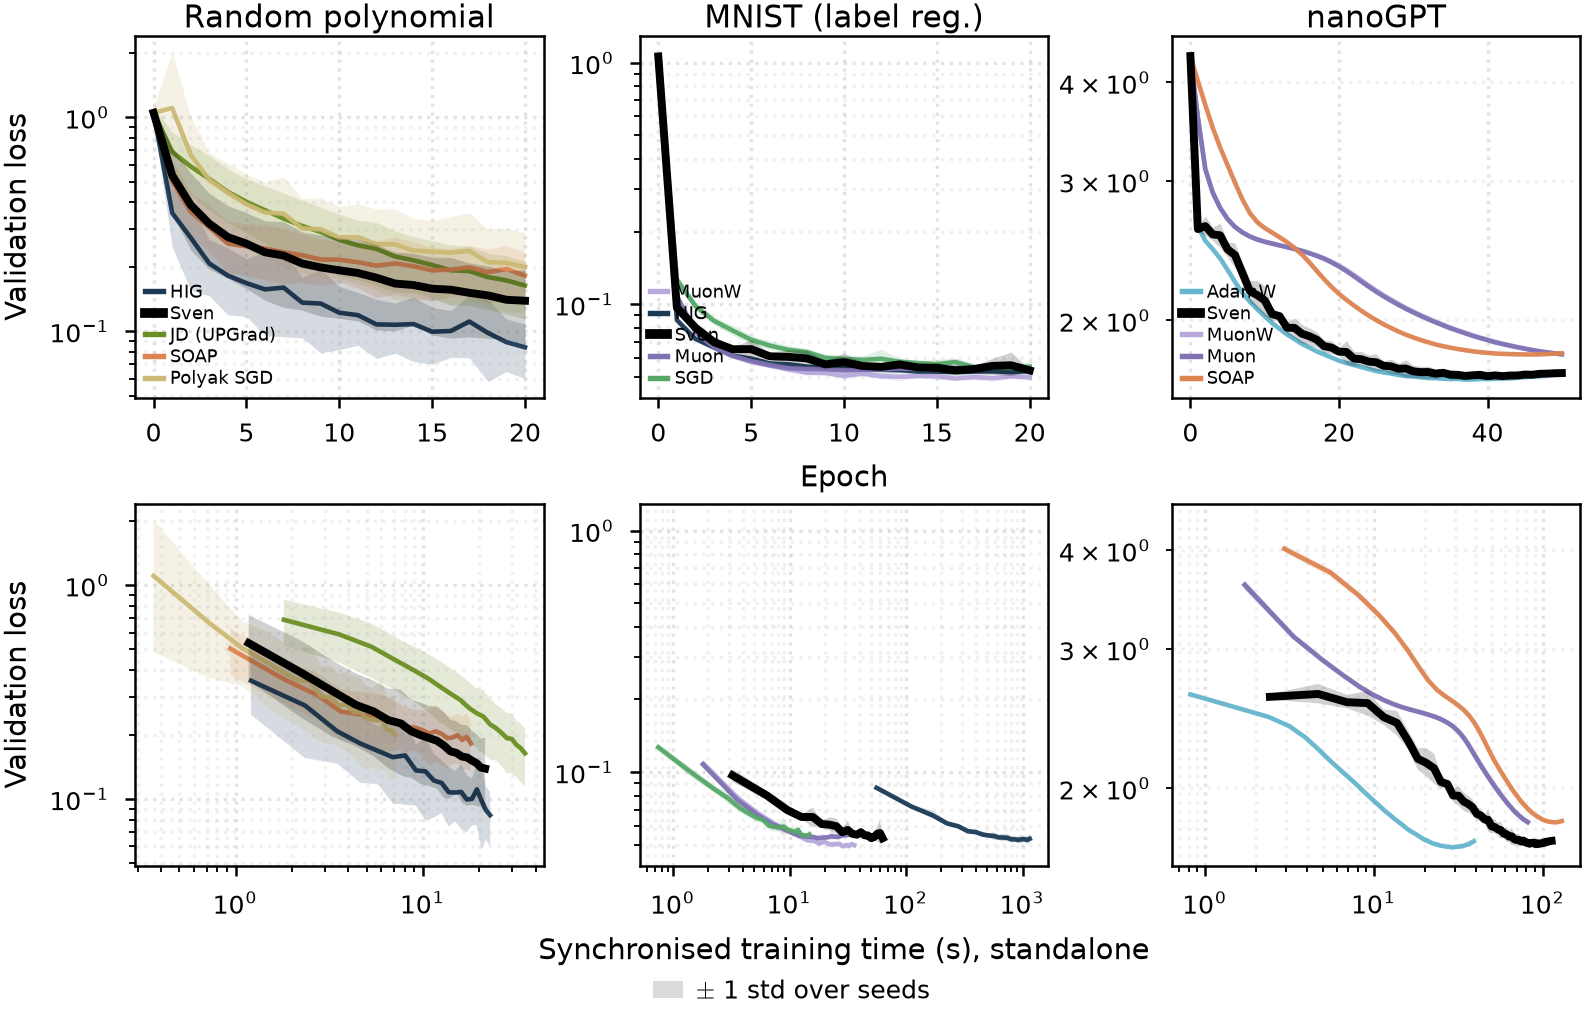

headline_curves: 5.28 x 3.41 in on the page (shown at 2x)


In [8]:
f = pf.make('headline_curves')
f.show(zoom=2)

In [9]:
# --- edit headline_curves -------------------------------------------------------
# its own knobs: aspect, extra_h, figure_legend_kw, figure_legend_methods, figure_legend_ncol, font_fraction, fraction, lw, methods, panel_legend, panel_legend_frame_lw, panel_legend_kw, panel_titles, scans, sven_lw, top_n, versus, xlabel_columns, ylabel_columns
# f = pf.make('headline_curves', aspect=0.86, extra_h=0.38, figure_legend_kw={'loc': 'outside lower center', 'fontsize': 6.0, 'handlelength': 1.2, 'columnspacing': 0.8})
# f = pf.make('headline_curves', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('headline_curves', aspect=0.95)              # ... and make the CLI agree

### Fig. 1 with every baseline

The committed default draws the front of the field plus Sven (`methods='top'`,
`top_n=5`), because five curves per 1.76-inch panel is what stays readable; the
all-methods version of the same figure is the separate appendix figure
`headline_curves_all`.

The cell below draws **Fig. 1 itself with every baseline**, which is what you want if the
main-text figure should carry the whole field. Nothing is written until you `save()`; to
make `python -m paper_assets` draw it that way as well, pin it.

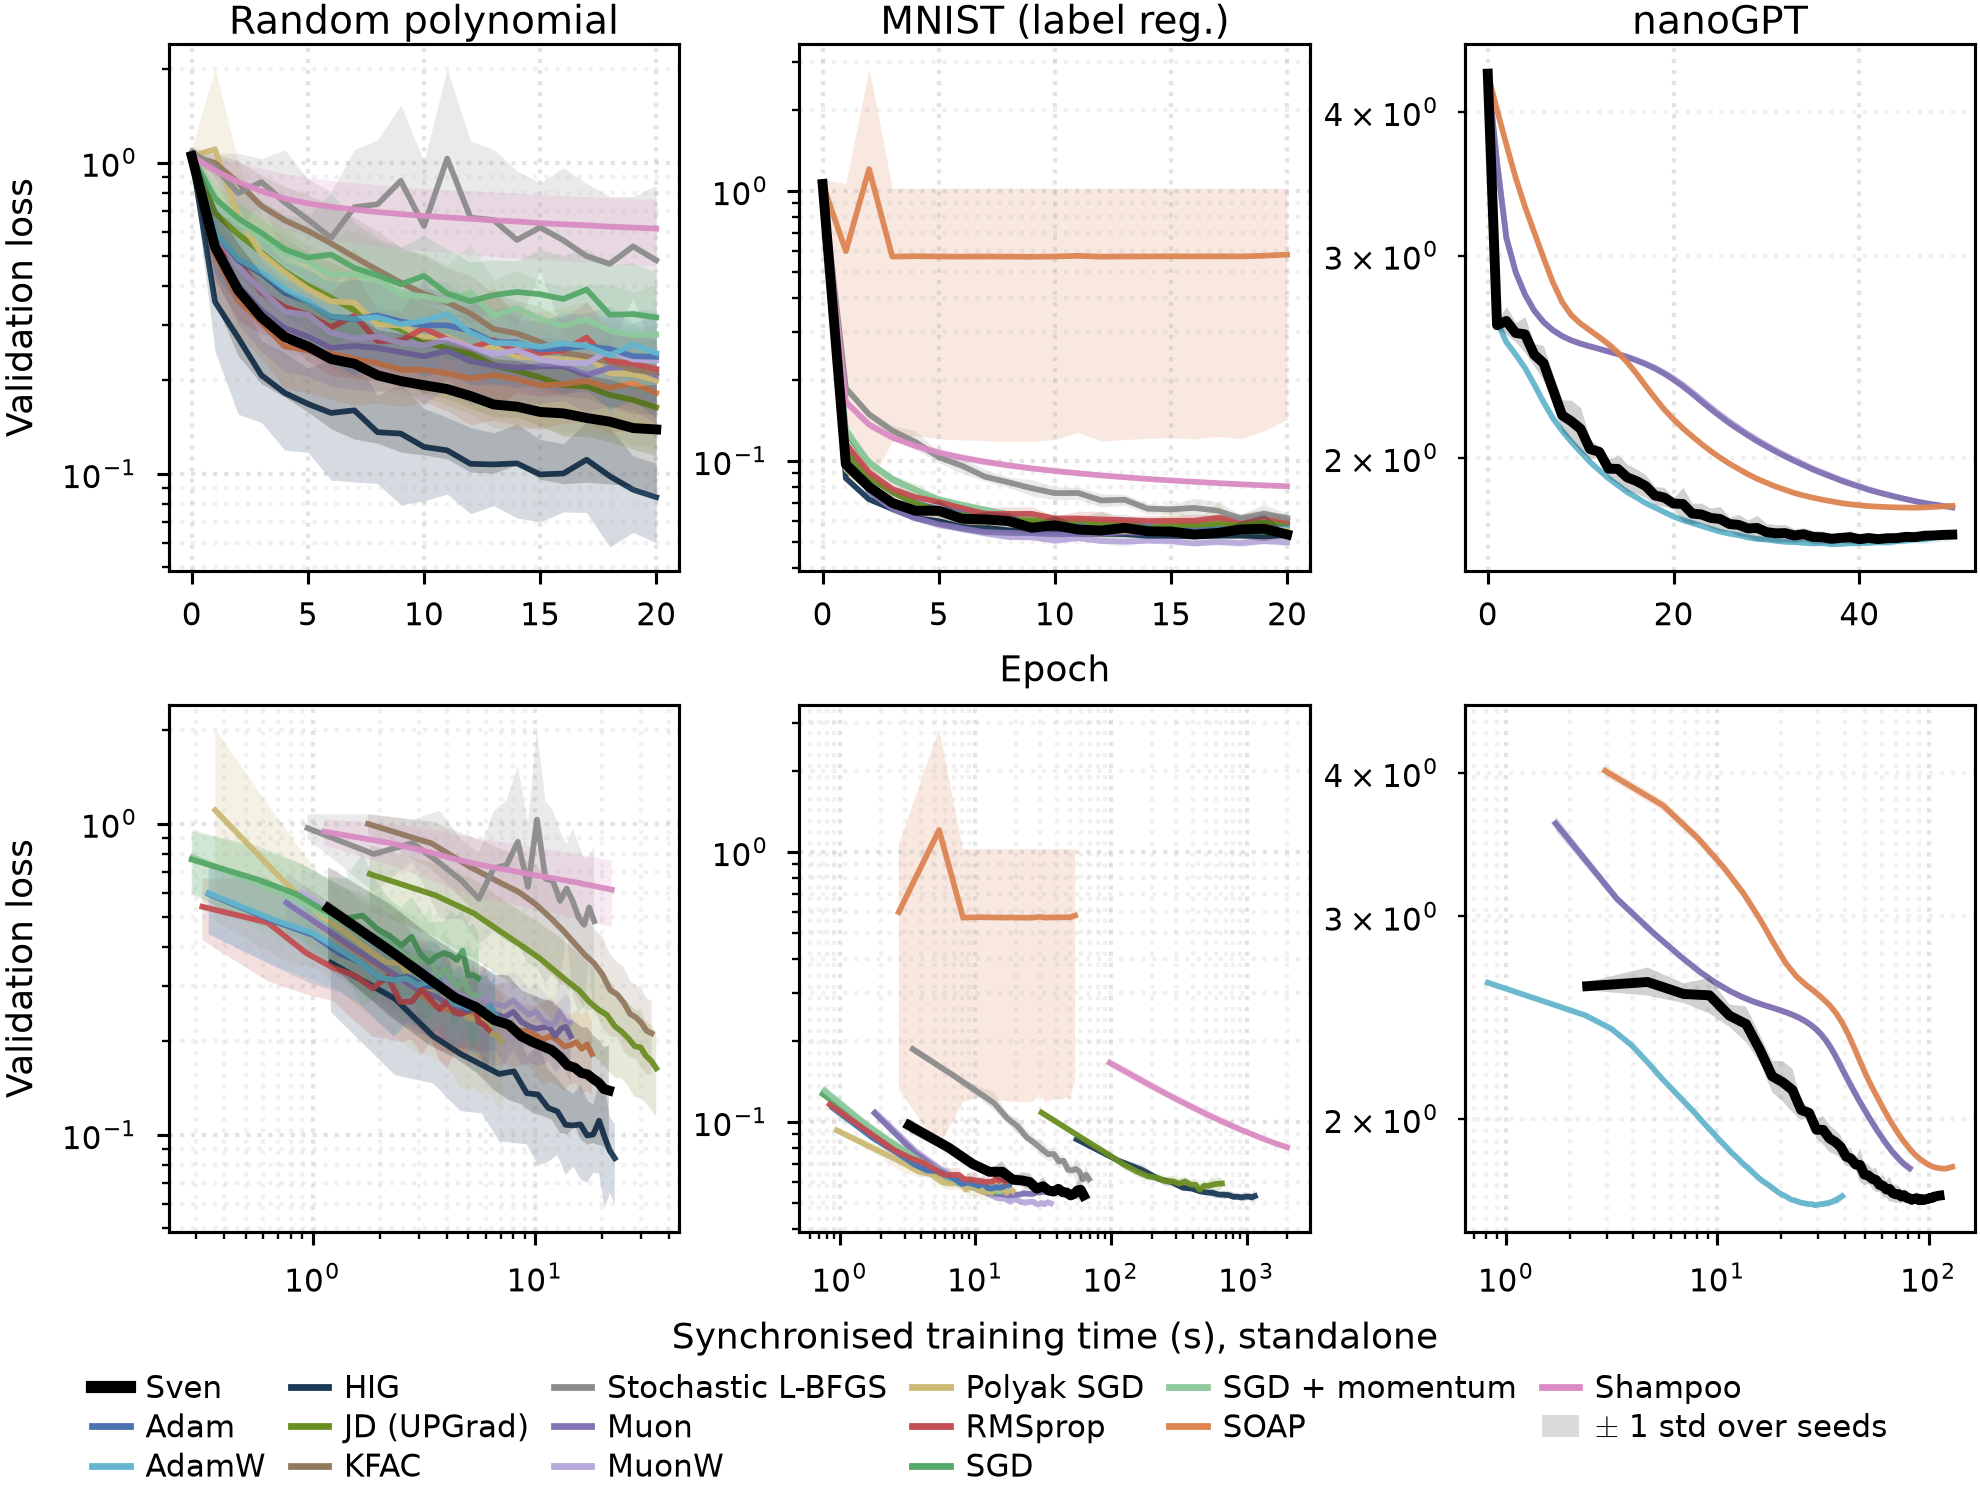

headline_curves: 5.28 x 4.02 in on the page (shown at 2.5x)


In [10]:
# `panel_legend=False` drops the per-panel key (15 entries do not fit in a 1.76 in
# panel) and `figure_legend_methods=True` puts ONE method key under the figure instead --
# without the second flag the figure would have no method key at all.  ncol=6 is what
# fits 16 entries across 5.28 in; ncol=8 clips them at both edges.
f_all = pf.make('headline_curves', methods='all',
                panel_legend=False, figure_legend_methods=True, figure_legend_ncol=6,
                aspect=0.9, extra_h=0.85)
f_all.show(zoom=2.5)

In [11]:
# keep it: pins `methods` (and the legend that makes room for 15 curves) for the
# notebook AND the CLI, then writes the paper PDF.
# pf.pin('headline_curves', methods='all', panel_legend=False,
#        figure_legend_methods=True, figure_legend_ncol=6, aspect=0.9, extra_h=0.85)
# pf.rebuild('headline_curves')
#
# and to go back to the committed version:
# pf.unpin('headline_curves'); pf.rebuild('headline_curves')

## `headline_curves_all`

F1, appendix version: the same panels with EVERY method that has a selected configuration, one shared method key instead of a per-panel one.

Its own knobs:

* `aspect` — default `0.86`
* `extra_h` — default `0.62`
* `figure_legend_kw` — default `{'loc': 'outside lower center', 'fontsize': 6.0, 'handlelength': 1.2, 'columnspacing': 0.8}`
* `figure_legend_methods` — default `True`
* `figure_legend_ncol` — default `None`
* `font_fraction` — default `0.32`
* `fraction` — default `0.32`
* `lw` — default `0.9`
* `methods` — default `'all'`
* `panel_legend` — default `False`
* `panel_legend_frame_lw` — default `0.3`
* `panel_legend_kw` — default `{'loc': 'lower left', 'fontsize': 4.3, 'handlelength': 1.0, 'handletextpad': 0.4, 'borderpad': 0.25, 'labelspacing': 0.18, 'borderaxespad': 0.3, 'framealpha': 0.82, 'fancybox': False, 'edgecolor': '0.8'}`
* `panel_titles` — default `True`
* `scans` — default `['polynomial_scan', 'mnist_scan_labelRegression', 'exp_nanogpt_speedrun']`
* `sven_lw` — default `1.9`
* `top_n` — default `5`
* `versus` — default `['epoch', 'time']`
* `xlabel_columns` — default `'middle'`
* `ylabel_columns` — default `'first'`


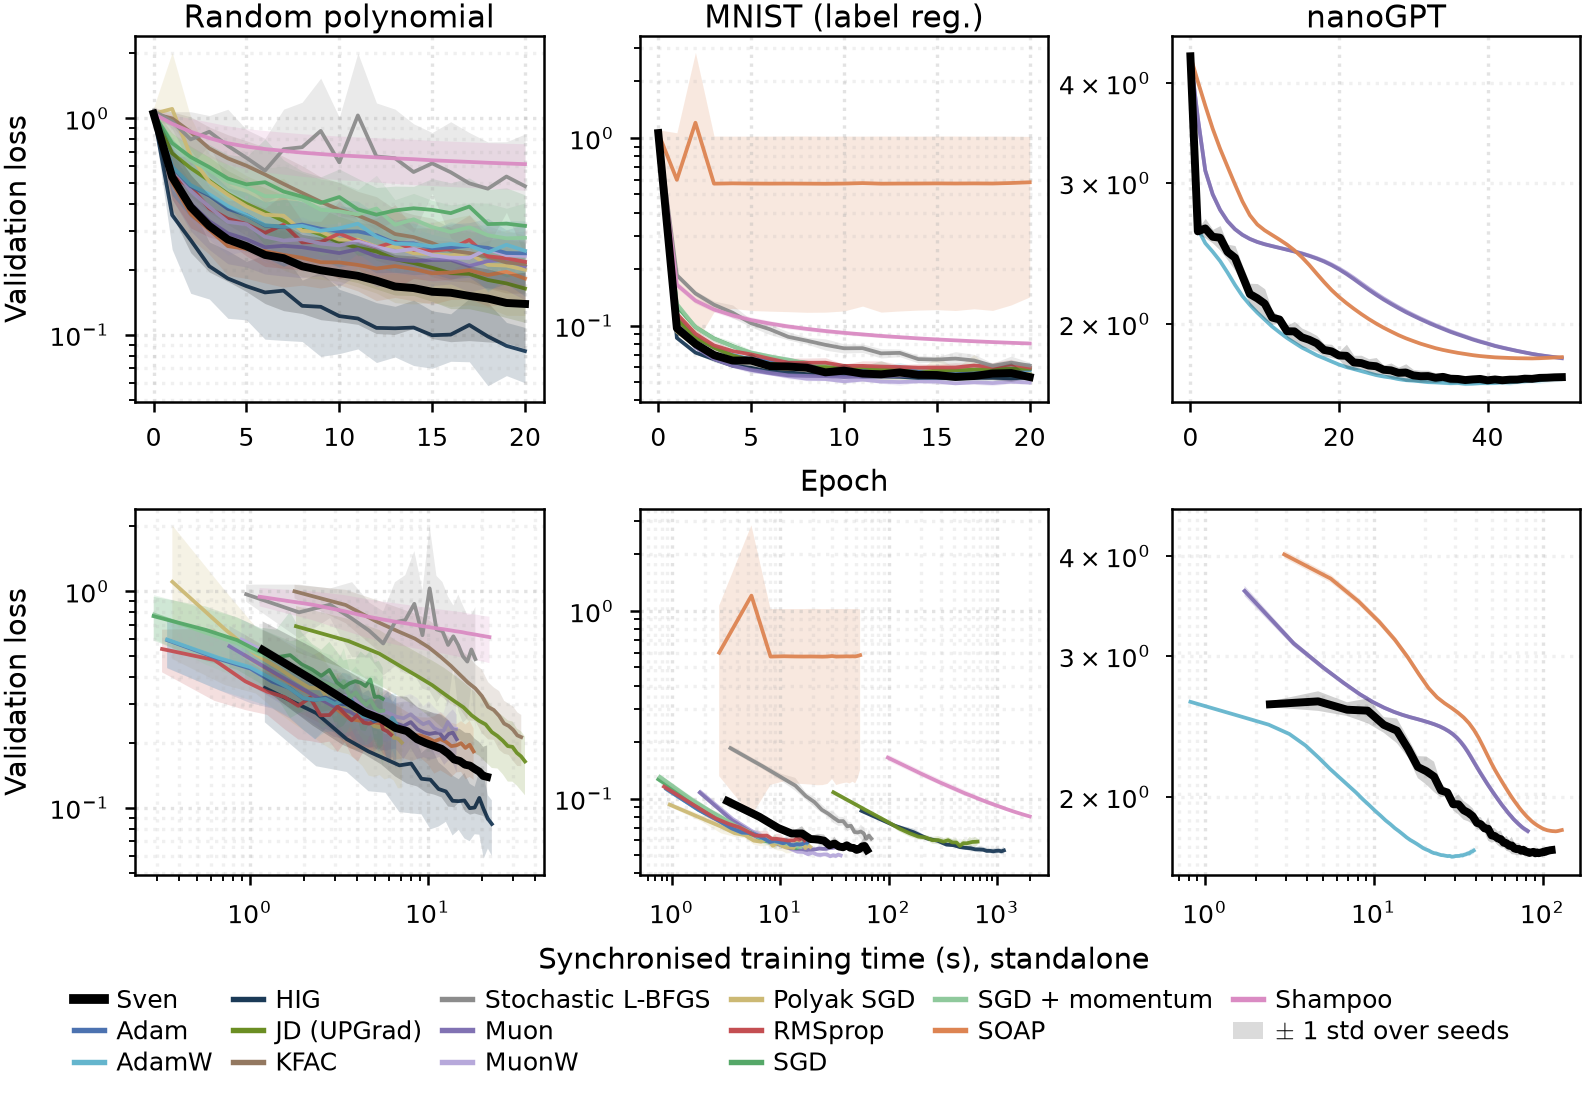

headline_curves_all: 5.28 x 3.65 in on the page (shown at 2x)


In [12]:
f = pf.make('headline_curves_all')
f.show(zoom=2)

In [13]:
# --- edit headline_curves_all -------------------------------------------------------
# its own knobs: aspect, extra_h, figure_legend_kw, figure_legend_methods, figure_legend_ncol, font_fraction, fraction, lw, methods, panel_legend, panel_legend_frame_lw, panel_legend_kw, panel_titles, scans, sven_lw, top_n, versus, xlabel_columns, ylabel_columns
# f = pf.make('headline_curves_all', aspect=0.86, extra_h=0.62, figure_legend_kw={'loc': 'outside lower center', 'fontsize': 6.0, 'handlelength': 1.2, 'columnspacing': 0.8})
# f = pf.make('headline_curves_all', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('headline_curves_all', aspect=0.95)              # ... and make the CLI agree

## `hparam_landscape`

F12 bottom: Sven's final-loss landscape over k at fixed rtol (top row) and over rtol at fixed k (bottom row), at the selected lr; the star is the selected configuration.

Its own knobs:

* `aspect` — default `1.0`
* `cmap` — default `'viridis'`
* `cmap_range` — default `[0.05, 0.9]`
* `extra_h` — default `0.3`
* `font_fraction` — default `0.32`
* `fraction` — default `0.245`
* `legend_handle_lw` — default `1.2`
* `lw` — default `0.9`
* `mark_selected` — default `True`
* `ms` — default `2.4`
* `panel_legend` — default `True`
* `panel_legend_kw` — default `{'frameon': True, 'framealpha': 0.88, 'edgecolor': 'none', 'borderpad': 0.25, 'fontsize': 4.4, 'ncol': 2, 'loc': 'best', 'handlelength': 0.9, 'labelspacing': 0.12, 'columnspacing': 0.5, 'title_fontsize': 4.4}`
* `rows` — default `[['k', 'rtol'], ['rtol', 'k']]`
* `saturation_factor` — default `1.05`
* `scans` — default `['toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression', 'mnist_scan_ce']`
* `selected_lw` — default `1.8`
* `star_mew` — default `0.9`
* `star_ms` — default `7`


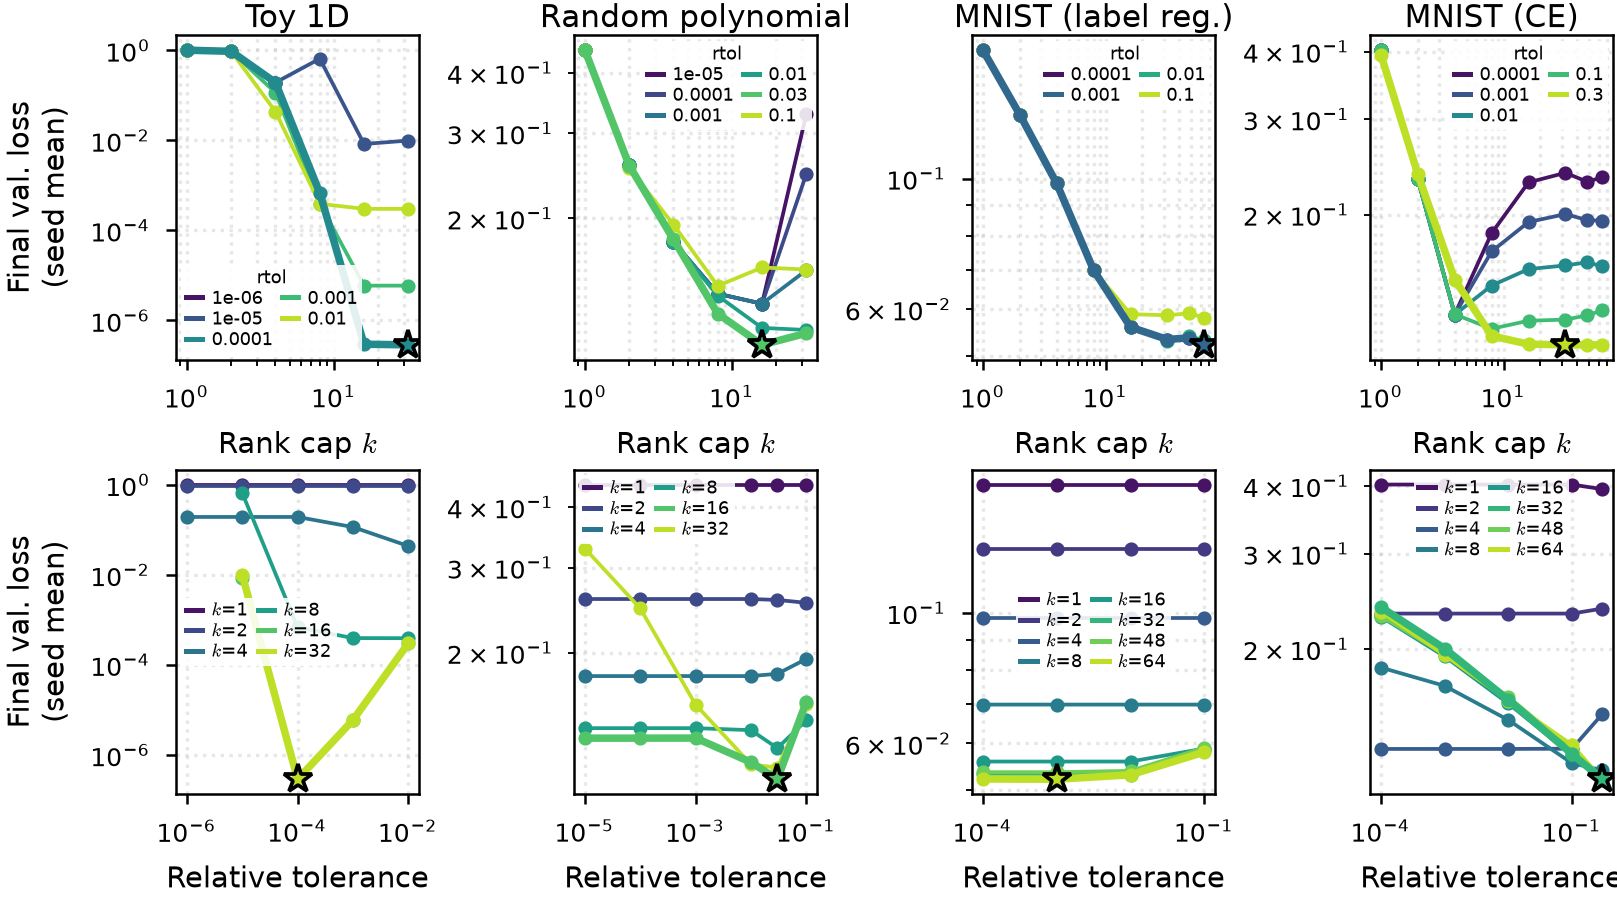

hparam_landscape: 5.39 x 2.99 in on the page (shown at 2x)


In [14]:
f = pf.make('hparam_landscape')
f.show(zoom=2)

In [15]:
# --- edit hparam_landscape -------------------------------------------------------
# its own knobs: aspect, cmap, cmap_range, extra_h, font_fraction, fraction, legend_handle_lw, lw, mark_selected, ms, panel_legend, panel_legend_kw, rows, saturation_factor, scans, selected_lw, star_mew, star_ms
# f = pf.make('hparam_landscape', aspect=1.0, cmap='viridis', cmap_range=[0.05, 0.9])
# f = pf.make('hparam_landscape', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('hparam_landscape', aspect=0.95)              # ... and make the CLI agree

## `k_sweeps`

F12 top: Sven's k sweep at each scan's SELECTED (lr, rtol); the thick curve is the selected k.

Its own knobs:

* `aspect` — default `1.05`
* `axis` — default `'k'`
* `band_alpha` — default `0.15`
* `cmap` — default `'viridis'`
* `cmap_range` — default `[0.05, 0.9]`
* `extra_h` — default `0.42`
* `font_fraction` — default `0.32`
* `fraction` — default `0.245`
* `legend_handle_lw` — default `1.4`
* `lw` — default `1.0`
* `panel_legend` — default `True`
* `panel_legend_kw` — default `{'frameon': True, 'framealpha': 0.88, 'edgecolor': 'none', 'borderpad': 0.25, 'fontsize': 4.8, 'ncol': 2, 'loc': 'upper right', 'handlelength': 1.0, 'labelspacing': 0.15, 'columnspacing': 0.6}`
* `scans` — default `['toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression', 'mnist_scan_ce']`
* `selected_lw` — default `1.9`
* `selected_note` — default `True`
* `selected_note_fontsize` — default `5.4`
* `selected_note_xy` — default `[0.03, 0.03]`
* `which` — default `'val'`


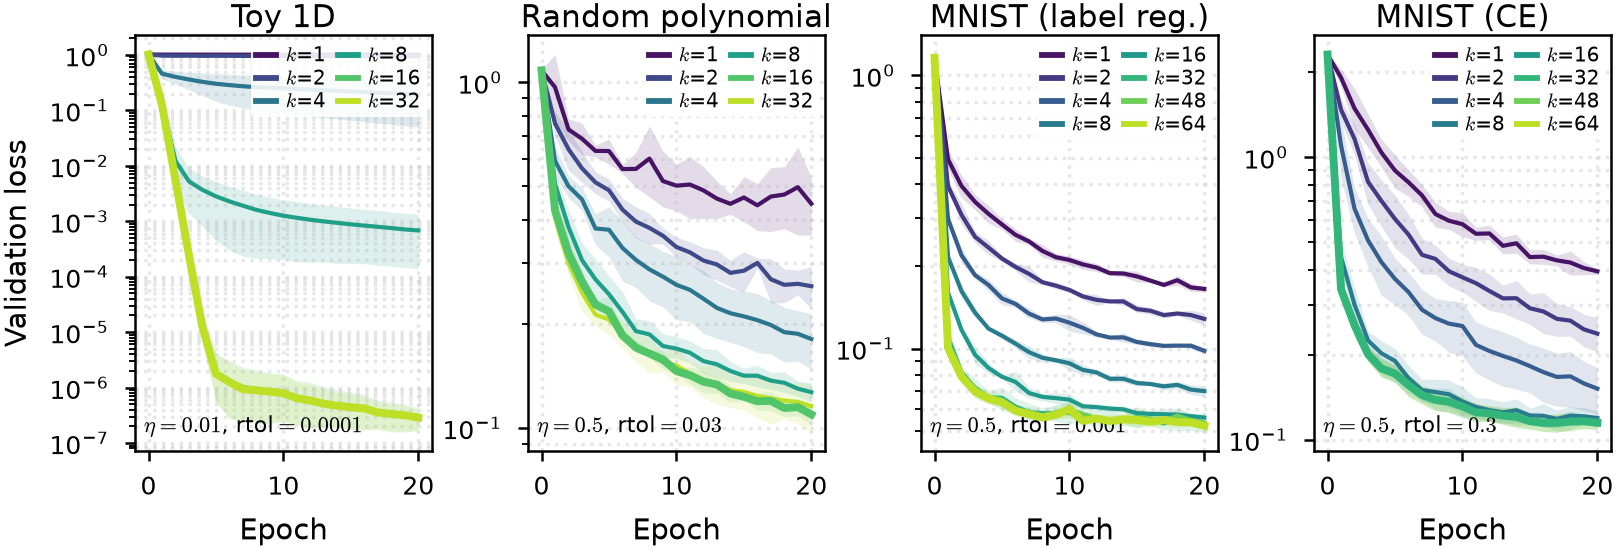

k_sweeps: 5.39 x 1.83 in on the page (shown at 2x)


In [16]:
f = pf.make('k_sweeps')
f.show(zoom=2)

In [17]:
# --- edit k_sweeps -------------------------------------------------------
# its own knobs: aspect, axis, band_alpha, cmap, cmap_range, extra_h, font_fraction, fraction, legend_handle_lw, lw, panel_legend, panel_legend_kw, scans, selected_lw, selected_note, selected_note_fontsize, selected_note_xy, which
# f = pf.make('k_sweeps', aspect=1.05, axis='k', band_alpha=0.15)
# f = pf.make('k_sweeps', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('k_sweeps', aspect=0.95)              # ... and make the CLI agree

## What is pinned

Everything this notebook has pinned, i.e. what `python -m paper_assets` will replay. `pf.unpin(<name>)` drops one, `pf.unpin()` drops them all.

In [18]:
pf.pinned()

{}